# Limits of RNNs: vanishing gradients

This notebook shows how a tiny RNN can learn to generate text, and that the influence of early text vanishes with each timestep: the **vanishing gradient problem**.

(This is also the [first experiment I attempted](https://github.com/jpivarski/rnn-oz) after reading [The Unreasonable Effectiveness of RNNs](https://karpathy.github.io/2015/05/21/rnn-effectiveness/) in 2018.)

In [1]:
import os
import math
import random
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

seed = 7
random.seed(seed)
torch.manual_seed(seed)
device = torch.device("cpu")

## Load the data (the Oz books)

Each nonempty line will be one training example. Because the books are already hard-wrapped, line-level generation gives us short, concrete sequences and makes timestep-by-timestep analysis easier later.

In [2]:
files = sorted(Path("data/oz").glob("*.txt"))
raw_lines = []
for path in files:
    raw_lines.extend(path.read_text(encoding="utf-8").splitlines())

lines = [line.strip() for line in raw_lines if line.strip()]
max_len = 80
lines = [line[: max_len - 1] + "\n" for line in lines]

chars = sorted(set("".join(lines)))
pad_token = "<PAD>"
vocab = [pad_token] + chars
stoi = {ch: i for i, ch in enumerate(vocab)}
itos = {i: ch for ch, i in stoi.items()}
pad_id = stoi[pad_token]
vocab_size = len(vocab)
seq_len = max_len - 1

def encode(text):
    return [stoi[ch] for ch in text]

def decode(ids):
    return "".join(itos[i] for i in ids if i != pad_id)

encoded = torch.full((len(lines), max_len), pad_id, dtype=torch.long)
for i, line in enumerate(lines):
    ids = torch.tensor(encode(line), dtype=torch.long)
    encoded[i, : len(ids)] = ids

x_data = encoded[:, :-1]
y_data = encoded[:, 1:]
train_ds = TensorDataset(x_data, y_data)

print(f"books: {len(files)}")
print(f"nonempty lines: {len(lines):,}")
print(f"vocab size (plus PAD): {vocab_size}")
print(f"training sequence length: {seq_len}")
print()
for sample in lines[:5]:
    print(repr(sample))

books: 14
nonempty lines: 56,131
vocab size (plus PAD): 77
training sequence length: 79

"The train from 'Frisco was very late.  It should have arrived at\n"
"Hugson's Siding at midnight, but it was already five o'clock and the\n"
'gray dawn was breaking in the east when the little train slowly rumbled\n'
'up to the open shed that served for the station-house.  As it came to a\n'
'stop the conductor called out in a loud voice:\n'

## Define a small, inspectable RNN

We will not use `nn.RNN` here. Instead we write the recurrence ourselves so the hidden-state update is explicit:

$$
 h_t = \sigma(W_{xh} x_t + W_{hh} h_{t-1} + b_h), \qquad
 y_t = W_{hy} h_t + b_y.
$$

Because the hidden activation is logistic, each timestep also introduces a factor of $\sigma'(z_t) = h_t (1 - h_t)$, which is at most $1/4$. That will matter when we unroll backpropagation through time.

In [3]:
class SimpleCharRNN(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        scale = 0.08
        self.W_xh = nn.Parameter(torch.randn(vocab_size, hidden_size) * scale)
        self.W_hh = nn.Parameter(torch.randn(hidden_size, hidden_size) * scale)
        self.b_h = nn.Parameter(torch.zeros(hidden_size))
        self.W_hy = nn.Parameter(torch.randn(hidden_size, vocab_size) * scale)
        self.b_y = nn.Parameter(torch.zeros(vocab_size))

    def forward_from_onehot(self, x_onehot, h0=None, return_states=False):
        batch_size, steps, _ = x_onehot.shape
        if h0 is None:
            h = torch.zeros(batch_size, self.hidden_size, device=x_onehot.device)
        else:
            h = h0
        logits = []
        states = []
        for t in range(steps):
            x_t = x_onehot[:, t, :]
            h = torch.sigmoid(x_t @ self.W_xh + h @ self.W_hh + self.b_h)
            y_t = h @ self.W_hy + self.b_y
            logits.append(y_t)
            states.append(h)
        logits = torch.stack(logits, dim=1)
        states = torch.stack(states, dim=1)
        if return_states:
            return logits, states
        return logits

    def forward(self, x_ids, h0=None, return_states=False):
        x_onehot = F.one_hot(x_ids, num_classes=vocab_size).float()
        return self.forward_from_onehot(x_onehot, h0=h0, return_states=return_states)

model = SimpleCharRNN(vocab_size=vocab_size, hidden_size=64).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-3)

## Training

For each line, the model sees every character except the last one and tries to predict the next character. We stop each example with a newline, so generation later can stop naturally at the end of a line.

To keep the model as simple as possible for Week 2, we will not change the architecture here. We only train longer so the text samples become a little more legible.

epoch 1: mean token NLL = 2.9496epoch 2: mean token NLL = 2.3758epoch 3: mean token NLL = 2.2130epoch 4: mean token NLL = 2.1189epoch 5: mean token NLL = 2.0490epoch 6: mean token NLL = 1.9941

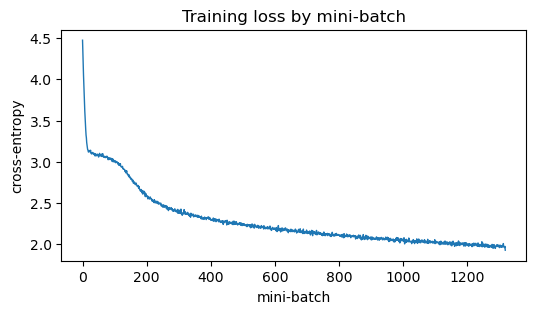


loss samples across training:
  batch   0: 4.4755
  batch 146: 2.8116
  batch 293: 2.4081
  batch 439: 2.2393
  batch 586: 2.2167
  batch 732: 2.1137
  batch 879: 2.0561
  batch 1025: 2.0259
  batch 1172: 2.0042
  batch 1319: 1.9260

In [4]:
batch_size = 256
epochs = 6
loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
loss_history = []

for epoch in range(epochs):
    total_loss = 0.0
    total_tokens = 0
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)
        loss = criterion(logits.reshape(-1, vocab_size), yb.reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        token_count = (yb != pad_id).sum().item()
        total_loss += loss.item() * token_count
        total_tokens += token_count
        loss_history.append(loss.item())

    mean_nll = total_loss / total_tokens
    print(f"epoch {epoch + 1}: mean token NLL = {mean_nll:.4f}")

plt.figure(figsize=(6, 3))
plt.plot(loss_history, lw=1)
plt.title("Training loss by mini-batch")
plt.xlabel("mini-batch")
plt.ylabel("cross-entropy")
plt.show()

sample_points = torch.linspace(0, len(loss_history) - 1, steps=10).long().tolist()
print()
print("loss samples across training:")
for idx in sample_points:
    print(f"  batch {idx:>3}: {loss_history[idx]:.4f}")

## See what it predicts

The model is tiny, so the samples will not be globally coherent, but they'll look kinda like English with some character names sprinkled in.

[My best result in 2018](https://raw.githubusercontent.com/jpivarski/rnn-oz/refs/heads/master/hyperparameters/charlevel_100_100_0.05.log) was

> I walked with it could councrawess were of finder Fairied with him my over this are for they warry build, for just his throne elach.

In [5]:
@torch.no_grad()
def generate_line(model, prompt="The ", max_new_chars=60, temperature=0.8):
    model.eval()
    h = torch.zeros(1, model.hidden_size, device=device)
    text = prompt
    if prompt:
        ids = torch.tensor([stoi[ch] for ch in prompt], dtype=torch.long, device=device).unsqueeze(0)
        _, states = model(ids, return_states=True)
        h = states[:, -1, :]
        last_id = ids[0, -1].item()
    else:
        last_id = stoi["T"]
        text = "T"

    for _ in range(max_new_chars):
        x = F.one_hot(torch.tensor([[last_id]], device=device), num_classes=vocab_size).float()
        logits, states = model.forward_from_onehot(x, h0=h, return_states=True)
        h = states[:, -1, :]
        logits = logits[0, -1] / temperature
        probs = torch.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1).item()
        next_char = itos[next_id]
        if next_char == "\n":
            break
        text += next_char
        last_id = next_id
    return text

for prompt in ["The ", '"I ', "Dorothy ", "Oz "]:
    print(f"{prompt:10s} → {generate_line(model, prompt=prompt)}")

The        → The ham thing of the Wele I he pughty sean allorond I sale sto h
"I         → "I in then!" hew the So in that and in they this.
Dorothy    → Dorothy if the beclund frombesty, and ow and the hajoy have hery way
Oz         → Oz bistontered hearn thillf and have and gop liod dobeyod him h

## Vanishing gradients

For a hidden state at time \(t\), the local Jacobian with respect to the previous hidden state is

$$
\frac{\partial h_t}{\partial h_{t-1}} = \operatorname{diag}(h_t (1 - h_t)) W_{hh}.
$$

So the influence of an earlier state $h_k$ on a later loss term passes through a product of many such factors:

$$
\frac{\partial L_t}{\partial h_k} = \frac{\partial L_t}{\partial h_t}
\prod_{j=k+1}^{t} \frac{\partial h_j}{\partial h_{j-1}}.
$$

With a sigmoid hidden activation, every step contributes a derivative term bounded by $1/4$, so the chain tends to shrink. We can see that directly by asking how much a later prediction depends on the **first word** of a real line from the corpus.

In [6]:
probe_line = next(line for line in lines if len(line.split()) >= 6 and 45 <= len(line) <= 70)
probe_ids = torch.tensor(encode(probe_line[:-1]), dtype=torch.long, device=device)
target_ids = torch.tensor(encode(probe_line[1:]), dtype=torch.long, device=device)
probe_onehot = F.one_hot(probe_ids, num_classes=vocab_size).float().unsqueeze(0)
probe_onehot.requires_grad_(True)

logits, states = model.forward_from_onehot(probe_onehot, return_states=True)
first_word = probe_line.split()[0]
first_span = len(first_word)
actual_text_positions = len(probe_line) - 1

grad_norms = []
for t in range(first_span, actual_text_positions):
    score = logits[0, t, target_ids[t]]
    grad = torch.autograd.grad(score, probe_onehot, retain_graph=True)[0][0, :first_span, :]
    grad_norms.append(grad.norm().item())

steps = list(range(first_span + 1, actual_text_positions + 1))
eps = 1e-12
log_norms = [math.log10(x + eps) for x in grad_norms]

print(repr(probe_line))
print(f"first word: {first_word!r}")
print()
print("timestep  grad-norm  log10(grad-norm)")
for step, value, log_value in list(zip(steps, grad_norms, log_norms))[:12]:
    print(f"{step:>8}  {value:.6f}  {log_value:>8.3f}")
print("...")
for step, value, log_value in list(zip(steps, grad_norms, log_norms))[-12:]:
    print(f"{step:>8}  {value:.6f}  {log_value:>8.3f}")

print()
print(f"early timestep norm: {grad_norms[0]:.6f}")
print(f"late timestep norm:  {grad_norms[-1]:.6f}")
print(f"log10 drop: {log_norms[0] - log_norms[-1]:.2f} orders of magnitude")

"The train from 'Frisco was very late.  It should have arrived at\n"
first word: 'The'

timestep  grad-norm  log10(grad-norm)
       4  16.584425     1.220
       5  5.372656     0.730
       6  3.232727     0.510
       7  2.925496     0.466
       8  1.315486     0.119
       9  0.792492    -0.101
      10  0.067058    -1.174
      11  0.162454    -0.789
      12  0.064098    -1.193
      13  0.058942    -1.230
      14  0.068477    -1.164
      15  0.010923    -1.962
...
      53  0.000000   -11.674
      54  0.000000   -11.829
      55  0.000000   -11.892
      56  0.000000   -11.957
      57  0.000000   -11.986
      58  0.000000   -11.996
      59  0.000000   -11.996
      60  0.000000   -11.994
      61  0.000000   -12.000
      62  0.000000   -12.000
      63  0.000000   -12.000
      64  0.000000   -12.000

early timestep norm: 16.584425
late timestep norm:  0.000000
log10 drop: 13.22 orders of magnitude